# BOTalign Iterative Alignment Viewer

This notebook is **visualization-only**. It does not run the alignment loop.

Use the script runner instead:
- `BOTalign/run_botalign_iterative_alignment.py`

The notebook reads saved outputs from `BOTalign/notebooks/cluster0_iterative_alignment_outputs` and lets you inspect:
- the latest completed round
- round-wise reference volumes
- metrics tables
- final rotations

In [1]:
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import pandas as pd

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
if not (PROJECT_ROOT / "utils_BO.py").exists():
    raise FileNotFoundError(
        "Run this notebook from BOTalign/notebooks so the parent folder contains utils_BO.py."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt.style.use("default")

In [10]:
OUTPUT_DIR = NOTEBOOK_DIR / "cluster0_iterative_alignment_outputs_40"
OUTPUT_DIR2 = NOTEBOOK_DIR / "cluster0_iterative_alignment_outputs"

RUNNER_SCRIPT = PROJECT_ROOT / "run_botalign_iterative_alignment.py"
ROUND_TO_VIEW = None  # Set to an integer round index to view a specific completed round.

OUTPUT_DIR, RUNNER_SCRIPT

(PosixPath('/home/anshu/subtmgr-align/BOTalign/notebooks/cluster0_iterative_alignment_outputs_40'),
 PosixPath('/home/anshu/subtmgr-align/BOTalign/run_botalign_iterative_alignment.py'))

In [3]:
def load_mrc(path: Path, permissive: bool = False) -> np.ndarray:
    with mrcfile.open(path, permissive=permissive) as mrc:
        return np.array(mrc.data, dtype=np.float32)


def get_saved_reference_paths(output_dir: Path):
    refs = []
    for path in output_dir.glob("reference_round_*.mrc"):
        try:
            round_idx = int(path.stem.split("_")[-1])
        except ValueError:
            continue
        refs.append((round_idx, path))
    return sorted(refs, key=lambda item: item[0])


def load_optional_csv(path: Path):
    if path.exists() and path.stat().st_size > 0:
        return pd.read_csv(path)
    return None


def show_volume_slices(volume: np.ndarray, title_prefix: str):
    mid = volume.shape[0] // 2
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(volume[mid], cmap="gray")
    axes[0].set_title(f"{title_prefix}: XY")
    axes[1].imshow(volume[:, mid, :], cmap="gray")
    axes[1].set_title(f"{title_prefix}: XZ")
    axes[2].imshow(volume[:, :, mid], cmap="gray")
    axes[2].set_title(f"{title_prefix}: YZ")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()

In [7]:
progress_df = load_optional_csv(OUTPUT_DIR / "current_progress.csv")
reference_stats_df = load_optional_csv(OUTPUT_DIR / "reference_stats.csv")
round_runtime_summary_df = load_optional_csv(OUTPUT_DIR / "round_runtime_summary.csv")
metrics_df = load_optional_csv(OUTPUT_DIR / "alignment_metrics.csv")
final_rotations_df = load_optional_csv(OUTPUT_DIR / "final_rotations.csv")
saved_references = get_saved_reference_paths(OUTPUT_DIR)

print(f"Runner script: {RUNNER_SCRIPT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Saved reference files: {len(saved_references)}")
if saved_references:
    print("Available rounds:", [round_idx for round_idx, _ in saved_references])

if progress_df is not None:
    display(progress_df)
if round_runtime_summary_df is not None:
    display(round_runtime_summary_df)
if reference_stats_df is not None:
    display(reference_stats_df)
if final_rotations_df is not None:
    display(final_rotations_df.head())
if metrics_df is not None:
    display(metrics_df.head())

Runner script: /home/anshu/subtmgr-align/BOTalign/run_botalign_iterative_alignment.py
Output directory: /home/anshu/subtmgr-align/BOTalign/notebooks/cluster0_iterative_alignment_outputs_40
Saved reference files: 3
Available rounds: [0, 1, 2]


,round,status,processed_subtomograms,total_subtomograms,reference_path,rotations_path,metrics_path
0,2,round_complete,40,40,/home/anshu/subtmgr-align/BOTalign/notebooks/c...,/home/anshu/subtmgr-align/BOTalign/notebooks/c...,/home/anshu/subtmgr-align/BOTalign/notebooks/c...


,round,mean_runtime_s
0,1,29.768496
1,2,29.209142


,round,mean,std,min,max,l2_norm
0,0,7.517308e-10,0.178649,-1.745451,1.631434,155.082153
1,1,-2.288097e-09,0.170037,-1.109246,1.391495,147.606064
2,2,-2.085610e-09,0.171730,-1.125807,1.268975,149.076279


,round,subtomogram_id,file_name,runtime_s,r00,r01,r02,r10,r11,r12,r20,r21,r22
0,2,0,0.mrc,30.150791,0.880993,0.332680,0.336415,0.294323,0.171355,-0.940219,-0.370439,0.927341,0.053047
1,2,1,1.mrc,30.009064,0.743478,-0.056896,-0.666335,-0.667615,-0.121413,-0.734540,-0.039110,0.990970,-0.128252
2,2,2,2.mrc,30.163687,0.958890,0.115134,0.259372,0.027213,0.872477,-0.487897,-0.282470,0.474898,0.833476
3,2,3,3.mrc,30.588926,0.862494,0.316239,-0.395092,0.435338,-0.065558,0.897877,0.258042,-0.946412,-0.194214
4,2,4,4.mrc,30.691283,0.807484,0.262860,0.528086,0.559549,-0.057903,-0.826772,-0.186748,0.963095,-0.193839


,round,subtomogram_id,file_name,runtime_s,r00,r01,r02,r10,r11,r12,r20,r21,r22
0,1,0,0.mrc,29.425862,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
1,1,1,1.mrc,28.880091,0.726566,0.226003,0.648864,0.361295,-0.928926,-0.081009,0.584439,0.293289,-0.756580
2,1,2,2.mrc,28.746415,0.466757,-0.743157,0.479432,-0.765674,-0.068279,0.639594,-0.442584,-0.665624,-0.600886
3,1,3,3.mrc,28.994074,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
4,1,4,4.mrc,29.466087,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000


Viewing: /home/anshu/subtmgr-align/BOTalign/notebooks/cluster0_iterative_alignment_outputs_40/final_reference.mrc


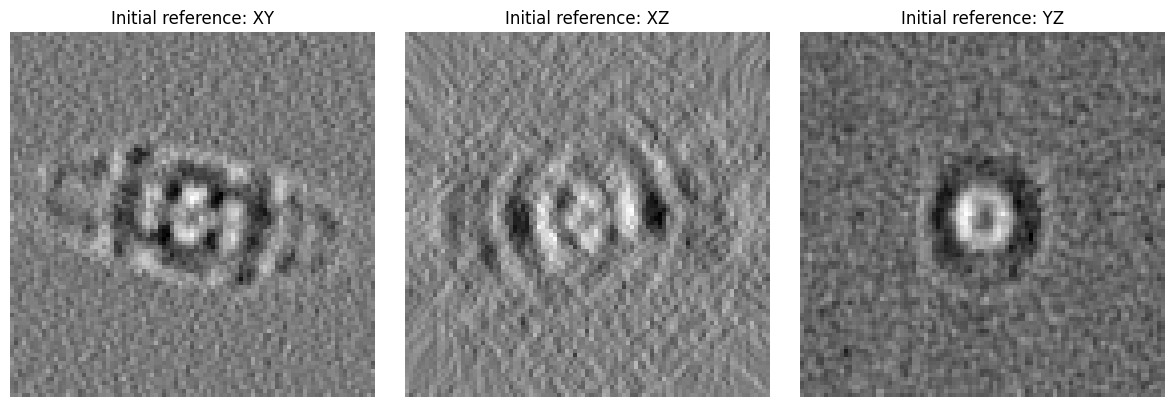

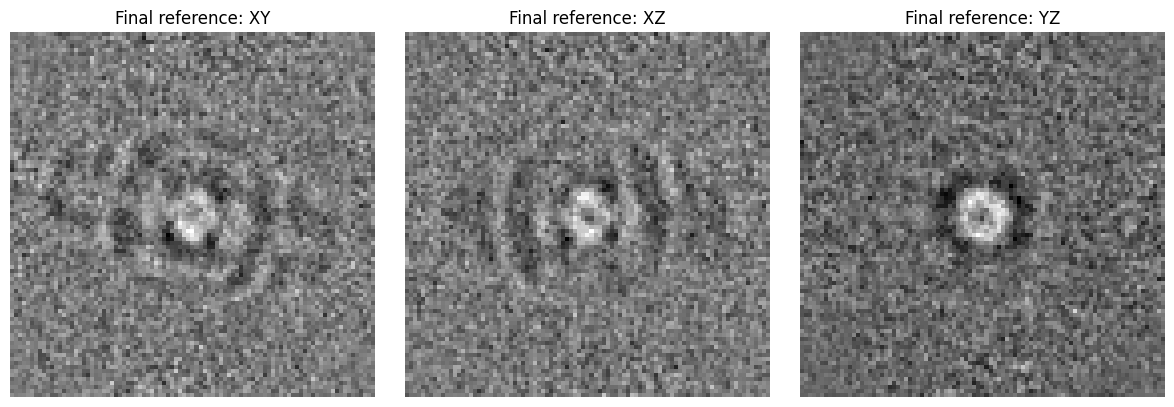

In [12]:
initial_reference_path = OUTPUT_DIR / "reference_round_00.mrc"
if not initial_reference_path.exists():
    raise FileNotFoundError(
        f"{initial_reference_path} does not exist yet. Run the script first."
    )

initial_reference = load_mrc(initial_reference_path, permissive=False)

if ROUND_TO_VIEW is None:
    if (OUTPUT_DIR / "final_reference.mrc").exists():
        selected_reference_path = OUTPUT_DIR / "final_reference.mrc"
        selected_label = "Final reference"
    elif saved_references:
        round_idx, path = saved_references[-1]
        selected_reference_path = path
        selected_label = f"Reference round {round_idx:02d}"
    else:
        selected_reference_path = initial_reference_path
        selected_label = "Initial reference"
else:
    selected_reference_path = OUTPUT_DIR / f"reference_round_{ROUND_TO_VIEW:02d}.mrc"
    if not selected_reference_path.exists():
        raise FileNotFoundError(f"{selected_reference_path} does not exist.")
    selected_label = f"Reference round {ROUND_TO_VIEW:02d}"

selected_reference = load_mrc(selected_reference_path, permissive=False)

show_volume_slices(initial_reference, "Initial reference")
show_volume_slices(selected_reference, selected_label)

print(f"Viewing: {selected_reference_path}")

## Notes

- Run alignment with `run_botalign_iterative_alignment.py`, not from this notebook.
- This notebook only reads saved files from disk.
- By default it shows the final reference if available, otherwise the latest completed round.
- Set `ROUND_TO_VIEW` in the config cell if you want to inspect a specific round.